In [417]:
# =========================
# 1. IMPORTS
# =========================
import wfdb
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

In [418]:
base_path = r"C:\Users\LapTechnology\PyCharmMiscProject\mit-bih-noise-stress-test-database-1.0.0\mit-bih-noise-stress-test-database-1.0.0"

records = [
    "118e00", "118e06", "118e12",
    "119e00", "119e06", "119e12"
]

noise_types = ["bw", "em", "ma"]

In [419]:
X = []
y = []

window = 300

In [420]:
step = window // 2

for rec in records:
    record = wfdb.rdrecord(base_path + "\\" + rec)
    signal = record.p_signal[:, 0]

    for i in range(0, len(signal) - window, step):
        segment = signal[i:i+window]
        X.append(segment)
        y.append("clean")

In [421]:
for noise in noise_types:
    record = wfdb.rdrecord(base_path + "\\" + noise)
    signal = record.p_signal[:, 0]
    for i in range(0, len(signal) - window, step):
        X.append(signal[i:i+window])
        y.append(noise)

In [422]:
X = np.array(X)
y = np.array(y)

print("Dataset shape:", X.shape)

Dataset shape: (38988, 300)


In [423]:
X = X.astype(np.float32)

for i in range(len(X)):

    seg = X[i]

    # 1. Remove DC shift
    seg = seg - np.mean(seg)

    # 2. Normalize amplitude
    seg = seg / (np.std(seg) + 1e-8)

    # 3. Smooth noise slightly (optional but strong)
    seg = np.convolve(seg, np.ones(5)/5, mode='same')

    X[i] = seg

In [424]:
le = LabelEncoder()
y = le.fit_transform(y)

print("Classes:", le.classes_)

Classes: ['bw' 'clean' 'em' 'ma']


In [425]:
X = X.reshape(X.shape[0], X.shape[1], 1)

In [426]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [427]:
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(zip(np.unique(y_train), weights))

print(class_weight_dict)

{np.int64(0): np.float64(2.249711482977496), np.int64(1): np.float64(0.3750060116385322), np.int64(2): np.float64(2.249711482977496), np.int64(3): np.float64(2.2503607503607506)}


In [428]:
model = models.Sequential()

model.add(layers.Conv1D(32, 5, padding='same', input_shape=(window, 1)))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling1D(2))

model.add(layers.Conv1D(64, 5, padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling1D(2))

model.add(layers.Conv1D(128, 3, padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling1D(2))

model.add(layers.GlobalAveragePooling1D())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(len(np.unique(y)), activation='softmax'))

C:\Users\LapTechnology\PyCharmMiscProject\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [429]:
# =========================
# Compile Model
# =========================
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [430]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

In [431]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_reducer = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [432]:
# =========================
#  Train Model
# =========================
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=25,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[early_stop, lr_reducer]
)

Epoch 1/25
488/488 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.7874 - loss: 0.4373 - val_accuracy: 0.8730 - val_loss: 0.3088 - learning_rate: 0.0010
Epoch 2/25
488/488 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.8473 - loss: 0.2563 - val_accuracy: 0.7644 - val_loss: 0.5736 - learning_rate: 0.0010
Epoch 3/25
488/488 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.8694 - loss: 0.2242 - val_accuracy: 0.9041 - val_loss: 0.2496 - learning_rate: 0.0010
Epoch 4/25
488/488 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.8816 - loss: 0.2033 - val_accuracy: 0.8334 - val_loss: 0.3670 - learning_rate: 0.0010
Epoch 5/25
485/488 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8866 - loss: 0.1906
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
488/488 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.8872 - loss: 0.1901 - val_accuracy: 0.8378 - val_loss: 0.4120 - learning_rate: 0.0010
Epoch 6/25
488/488 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9129 - los

In [433]:
# =========================
#  Evaluate Model
# =========================
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred, target_names=le.classes_))

244/244 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9411 - loss: 0.1436
Test Accuracy: 0.941138744354248
244/244 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
              precision    recall  f1-score   support

          bw       0.99      0.98      0.98       866
       clean       0.99      0.93      0.96      5199
          em       0.69      0.93      0.79       866
          ma       0.97      0.99      0.98       867

    accuracy                           0.94      7798
   macro avg       0.91      0.96      0.93      7798
weighted avg       0.95      0.94      0.94      7798



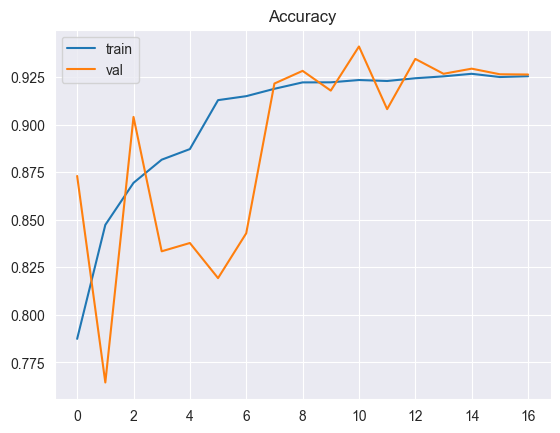

In [434]:
# =========================
#  Plot Training
# ========================
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy")
plt.legend()
plt.show()

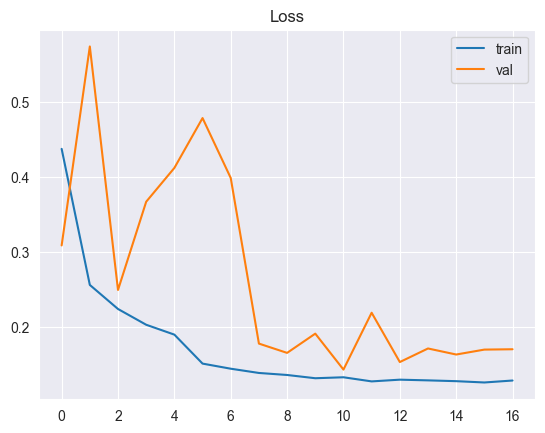

In [435]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()
plt.show()

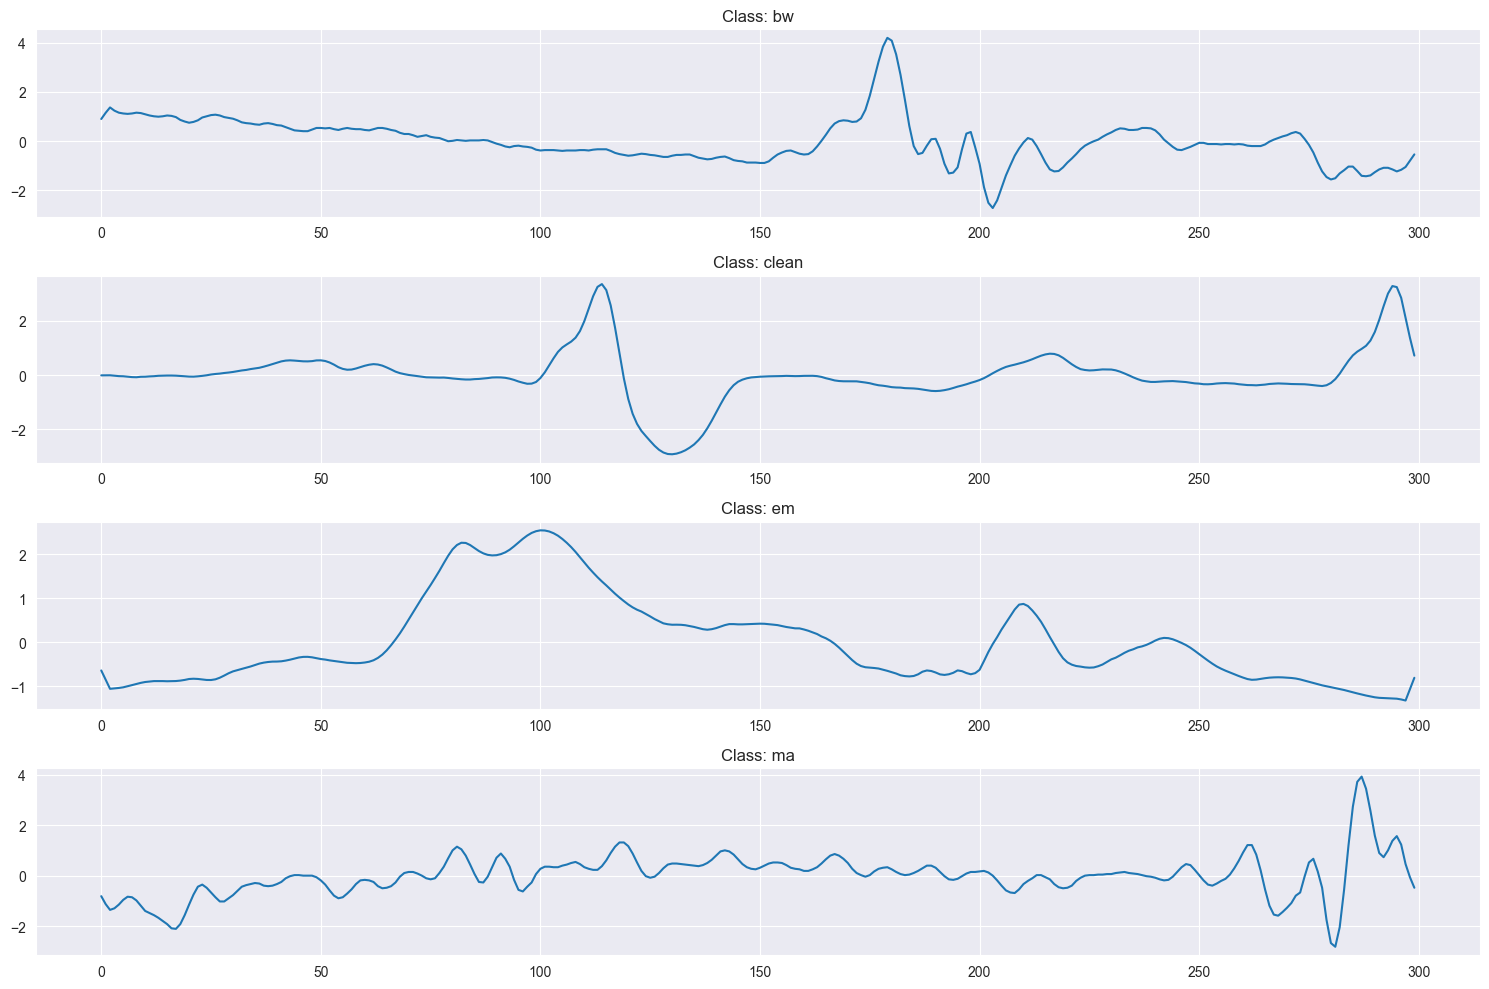

In [436]:
classes = np.unique(le.inverse_transform(y_test))
plt.figure(figsize=(15, 10))

for i, cls_name in enumerate(classes):
    idx = np.where(le.inverse_transform(y_test) == cls_name)[0][0]
    plt.subplot(len(classes), 1, i+1)
    plt.plot(X_test[idx].flatten())
    plt.title(f"Class: {cls_name}")
    plt.grid(True)

plt.tight_layout()
plt.show()

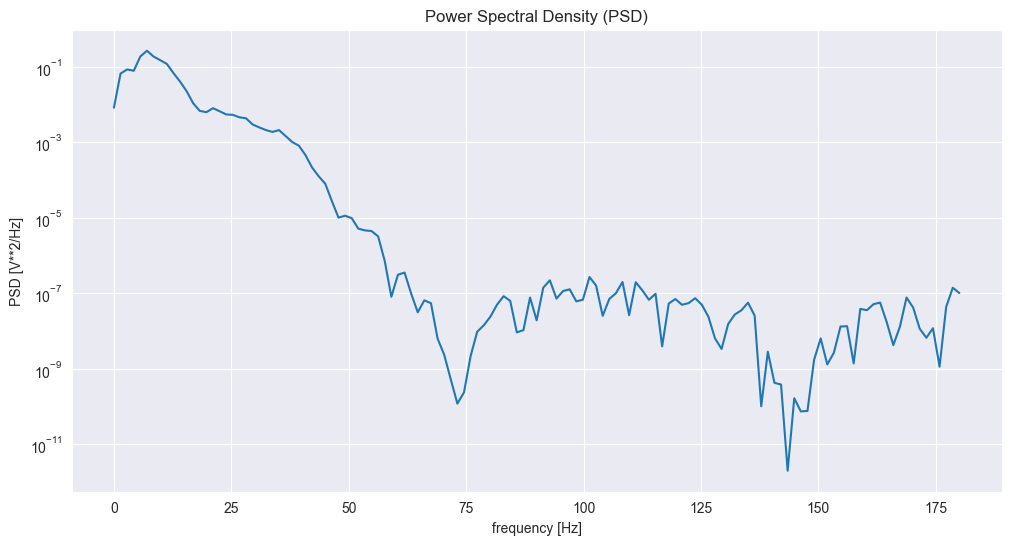

In [437]:
from scipy import signal as scipy_signal

plt.figure(figsize=(12, 6))
f, Pxx_den = scipy_signal.welch(X_test[0].flatten(), fs=360)
plt.semilogy(f, Pxx_den)
plt.title('Power Spectral Density (PSD)')
plt.xlabel('frequency [Hz]')
plt.ylabel('PSD [V**2/Hz]')
plt.show()

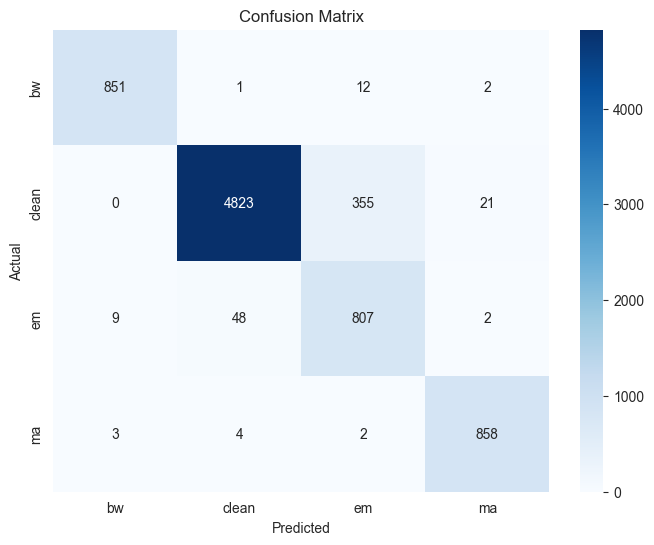

In [438]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()